# 01_EDA — Exploratory Data Analysis & Data Quality Audit
**Week 1 | Telco Customer Churn**

Covers:
1. Load data & fix TotalCharges blank-string bug
2. Collapse 'No internet service' pseudo-categories
3. Overall churn rate (class imbalance)
4. Churn by Contract type (H1)
5. Churn by Tenure bucket (H2)
6. Churn by Payment Method (H3)
7. Churn by OnlineSecurity (H4)
8. Churn by MonthlyCharges (H5)
9. Churn by SeniorCitizen (H6)
10. Churn by Services Count (H7)
11. CLV calculation
12. Hypothesis summary & save cleaned data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 1 — Fix TotalCharges Blank-String Bug

TotalCharges loads as `object` because 11 rows contain `" "` (blank string) instead of NaN.
These are new customers with `tenure = 0`.

In [2]:
# Show the bug
print('Before fix — dtype:', df['TotalCharges'].dtype)
blank_rows = df[df['TotalCharges'].str.strip() == '']
print(f'Blank string rows: {len(blank_rows)}')
print(blank_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

Before fix — dtype: object
Blank string rows: 11
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218  2923-ARZLG       0           19.70             
6670  4075-WKNIU       0           73.35             
6754  2775-SEFEE       0           61.90             


In [3]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print('After fix — dtype:', df['TotalCharges'].dtype)
print('Remaining NaNs:', df['TotalCharges'].isna().sum())

After fix — dtype: float64
Remaining NaNs: 0


## Step 2 — Data Types Check

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Step 3 — Collapse 'No internet service' Categories

6 columns use 'No internet service' which is semantically identical to 'No'.
Reducing categories simplifies future modeling.

In [5]:
service_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in service_cols:
    df[col] = df[col].replace('No internet service', 'No')

print(df[service_cols].apply(lambda c: c.unique()))

  OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV  \
0             No          Yes               No          No          No   
1            Yes           No              Yes         Yes         Yes   

  StreamingMovies  
0              No  
1             Yes  


## Step 4 — Overall Churn Rate

Expected: No ≈ 73.4%, Yes ≈ 26.6% → moderately imbalanced dataset.

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

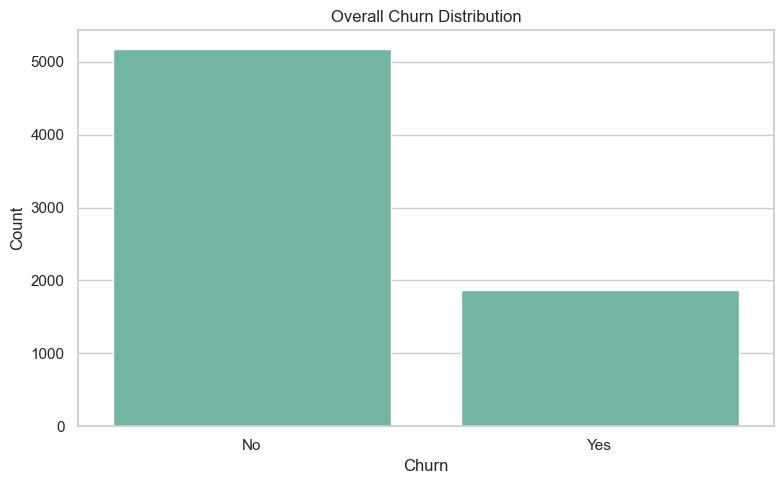

In [6]:
print(df['Churn'].value_counts(normalize=True) * 100)

sns.countplot(x='Churn', data=df)
plt.title('Overall Churn Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/churn_distribution.png', dpi=150)
plt.show()

In [7]:
# Binary target for groupby calculations
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

## H1 — Churn by Contract Type

Expected finding: Month-to-month customers churn the most. Two-year contracts churn the least.

Business Insight: Long-term contracts improve retention.

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


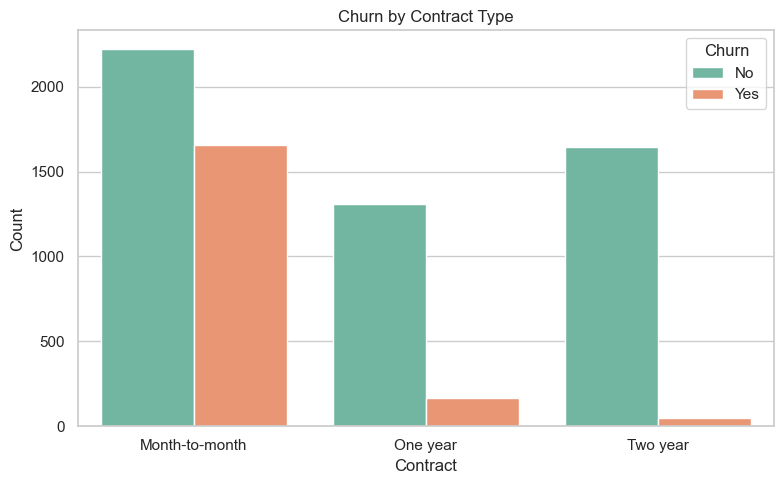

In [8]:
contract_churn_rate = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100
print(contract_churn_rate.round(2))

sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/churn_by_contract.png', dpi=150)
plt.show()

## H2 — Churn by Tenure Bucket

Expected finding: New customers (0-12 months) churn more frequently.

Business Insight: First-year customers require special attention.

Note: bins start at -1 so that tenure=0 customers are included in the '0-12' bucket.

Churn             No    Yes
tenure_bucket              
0-12           52.56  47.44
13-24          71.29  28.71
25-48          79.61  20.39
49-72          90.49   9.51


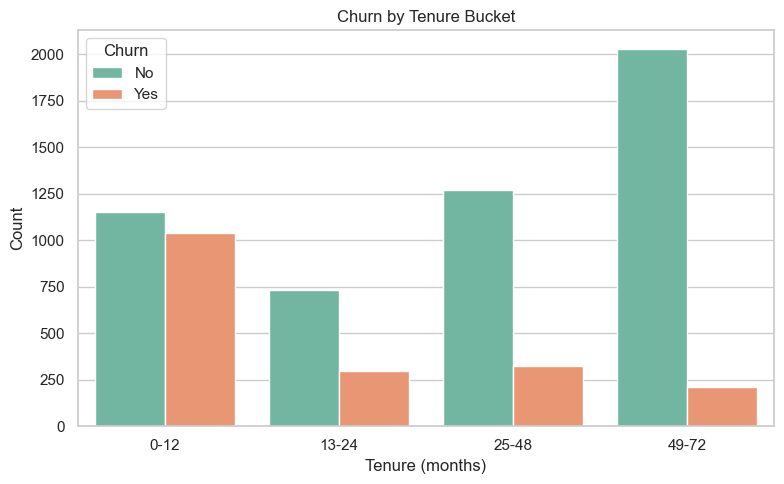

In [9]:
df['tenure_bucket'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 24, 48, 72],
    labels=['0-12', '13-24', '25-48', '49-72']
)

tenure_churn_rate = pd.crosstab(
    df['tenure_bucket'],
    df['Churn'],
    normalize='index'
) * 100
print(tenure_churn_rate.round(2))

sns.countplot(x='tenure_bucket', hue='Churn', data=df)
plt.title('Churn by Tenure Bucket')
plt.ylabel('Count')
plt.xlabel('Tenure (months)')
plt.tight_layout()
plt.savefig('../reports/churn_by_tenure.png', dpi=150)
plt.show()

## H3 — Churn by Payment Method

Expected finding: Electronic Check customers show higher churn.

Business Insight: Payment experience may influence retention.

Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11


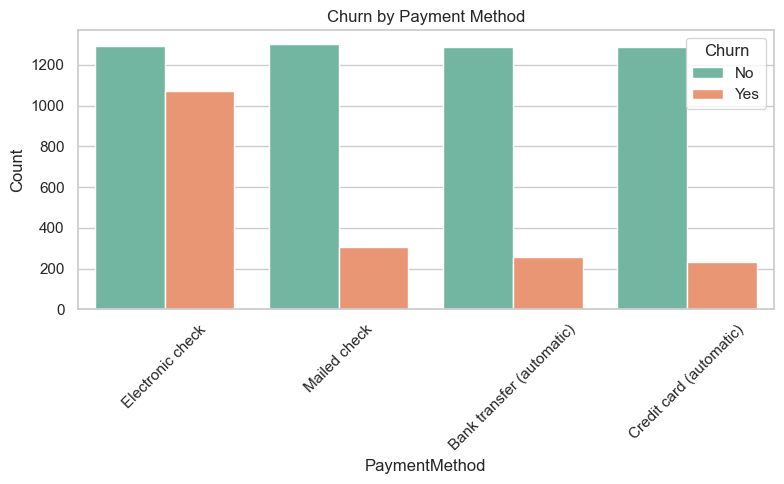

In [10]:
payment_churn_rate = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100
print(payment_churn_rate.round(2))

sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title('Churn by Payment Method')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/churn_by_payment.png', dpi=150)
plt.show()

## H4 — Churn by Online Security

Expected finding: Customers without OnlineSecurity churn significantly more.

Churn              No    Yes
OnlineSecurity              
No              68.67  31.33
Yes             85.39  14.61


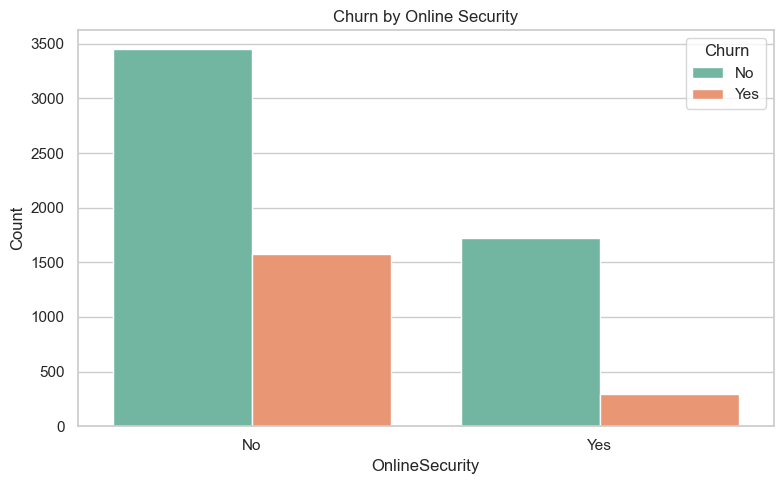

In [11]:
security_churn_rate = pd.crosstab(
    df['OnlineSecurity'],
    df['Churn'],
    normalize='index'
) * 100
print(security_churn_rate.round(2))

sns.countplot(x='OnlineSecurity', hue='Churn', data=df)
plt.title('Churn by Online Security')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/churn_by_security.png', dpi=150)
plt.show()

## H5 — Churn by Monthly Charges

Expected finding: Churned customers pay higher monthly charges on average.

Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


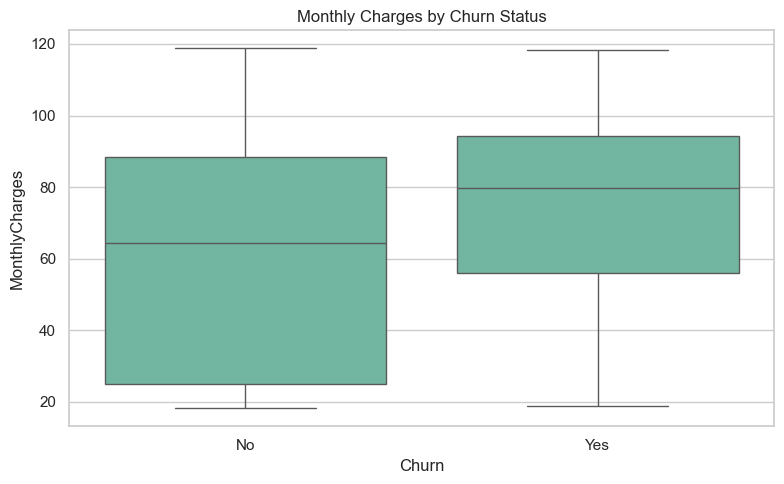

In [12]:
print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges by Churn Status')
plt.tight_layout()
plt.savefig('../reports/churn_by_monthly_charges.png', dpi=150)
plt.show()

## H6 — Churn by Senior Citizen

Expected finding: Senior citizens have a higher churn rate.

SeniorCitizen
0    23.6
1    41.7
Name: Churn_binary, dtype: float64


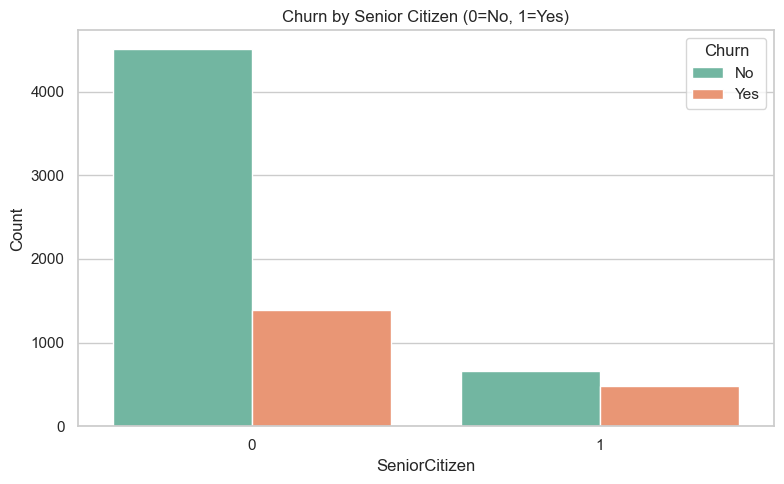

In [13]:
print(df.groupby('SeniorCitizen')['Churn_binary'].mean().round(3) * 100)

sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title('Churn by Senior Citizen (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/churn_by_senior.png', dpi=150)
plt.show()

## H7 — Churn by Number of Services

Expected finding: Customers with more bundled services churn less (higher switching cost).

services_count
0    21.4
1    45.8
2    35.8
3    27.4
4    22.3
5    12.4
6     5.3
Name: Churn_binary, dtype: float64


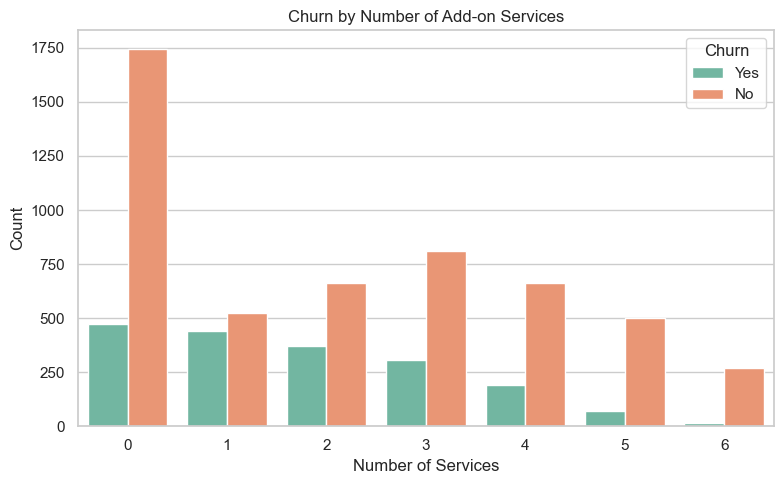

In [14]:
df['services_count'] = df[service_cols].apply(lambda row: (row == 'Yes').sum(), axis=1)

print(df.groupby('services_count')['Churn_binary'].mean().round(3) * 100)

sns.countplot(x='services_count', hue='Churn', data=df)
plt.title('Churn by Number of Add-on Services')
plt.xlabel('Number of Services')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/churn_by_services_count.png', dpi=150)
plt.show()

## CLV Calculation

CLV = MonthlyCharges × tenure

In [15]:
df['CLV'] = df['MonthlyCharges'] * df['tenure']
print(df.groupby('Churn')['CLV'].describe().round(2))

        count     mean      std    min     25%      50%      75%     max
Churn                                                                   
No     5174.0  2549.77  2328.40   0.00  574.56  1687.12  4244.81  8550.0
Yes    1869.0  1531.61  1886.77  18.85  137.90   700.00  2334.80  8481.6


## Hypothesis Summary

In [16]:
contract_rates = (
    df.groupby('Contract')['Churn_binary'].mean() * 100
)

hypotheses = {
    'H1: Month-to-month churn > One year AND Two year':
        (contract_rates['Month-to-month'] > contract_rates['One year'])
        and
        (contract_rates['Month-to-month'] > contract_rates['Two year']),
    'H2: 0-12 mo tenure has highest churn':
        df.groupby('tenure_bucket', observed=True)['Churn_binary'].mean().idxmax() == '0-12',
    'H3: Electronic check has highest churn':
        df.groupby('PaymentMethod')['Churn_binary'].mean().idxmax() == 'Electronic check',
    'H4: No OnlineSecurity churns more':
        df[df['OnlineSecurity']=='No']['Churn_binary'].mean() >
        df[df['OnlineSecurity']=='Yes']['Churn_binary'].mean(),
    'H5: Higher MonthlyCharges → higher churn':
        df[df['Churn']=='Yes']['MonthlyCharges'].mean() >
        df[df['Churn']=='No']['MonthlyCharges'].mean(),
    'H6: Senior citizens churn more':
        df[df['SeniorCitizen']==1]['Churn_binary'].mean() >
        df[df['SeniorCitizen']==0]['Churn_binary'].mean(),
    'H7: More services → lower churn':
        df.groupby('services_count')['Churn_binary'].mean().is_monotonic_decreasing,
}

for h, result in hypotheses.items():
    status = '✅ CONFIRMED' if result else '❌ REJECTED'
    print(f'{status} — {h}')

✅ CONFIRMED — H1: Month-to-month churn > One year AND Two year
✅ CONFIRMED — H2: 0-12 mo tenure has highest churn
✅ CONFIRMED — H3: Electronic check has highest churn
✅ CONFIRMED — H4: No OnlineSecurity churns more
✅ CONFIRMED — H5: Higher MonthlyCharges → higher churn
✅ CONFIRMED — H6: Senior citizens churn more
❌ REJECTED — H7: More services → lower churn


## Save Cleaned Data

In [17]:
import os
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/telco_churn_cleaned.csv', index=False)
print('✅ Cleaned data saved to data/processed/telco_churn_cleaned.csv')
print(f'   Rows: {len(df)} | Columns: {df.shape[1]}')

✅ Cleaned data saved to data/processed/telco_churn_cleaned.csv
   Rows: 7043 | Columns: 25
